In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd

In [2]:
from sklearn.cluster import KMeans
from sklearn.datasets import load_digits
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler

In [3]:
from data_science.plots import kmeans_metrics_plot, plot_clusters, plot_elbow, plot_pca_scatter


## Data


In [4]:
dataset = load_digits()
dataset.keys()

dict_keys(['data', 'target', 'frame', 'feature_names', 'target_names', 'images', 'DESCR'])

In [5]:
data = pd.DataFrame(
    dataset.data,
    columns=dataset.feature_names,
)

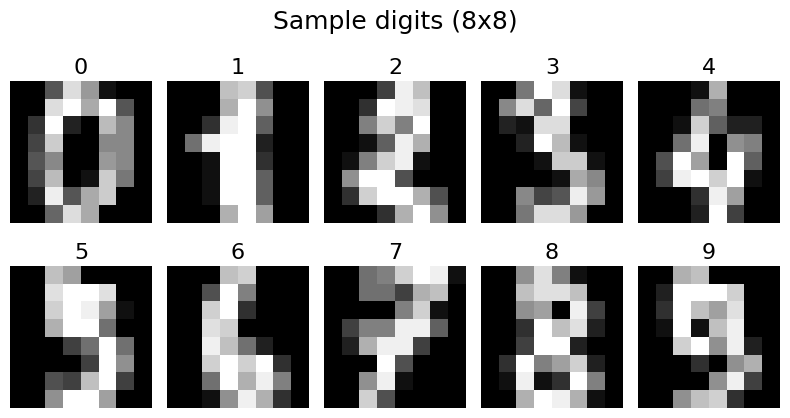

In [6]:
images = dataset.images
fig, axes = plt.subplots(2, 5, figsize=(8, 4.5))
plt.gray()
for ax, img, label in zip(axes.ravel(), images[:10], dataset.target[:10], strict=True):
    ax.imshow(img)
    ax.set_title(f'{label}', fontsize=16)
    ax.axis('off')
plt.suptitle('Sample digits (8x8)', fontsize=18)
plt.tight_layout()
plt.show()

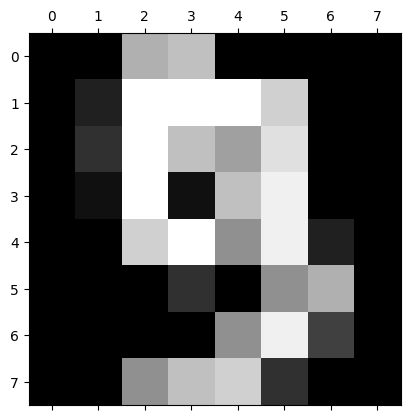

In [7]:
plt.matshow(dataset.data[9].reshape(8, 8))

## Prepare Data


In [8]:
RANDOM_STATE = 42
np.random.default_rng(RANDOM_STATE)

Generator(PCG64) at 0x1387327A0

In [9]:
X = data
y = dataset.target

In [10]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

In [11]:
X_train, X_test, y_train, y_test = train_test_split(
    X_scaled,
    y,
    test_size=0.2,
    random_state=RANDOM_STATE,
)

## PCA


In [12]:
pca_2d = PCA(
    n_components=2,
    random_state=RANDOM_STATE,
)
X_pca_2d = pca_2d.fit_transform(X_scaled)

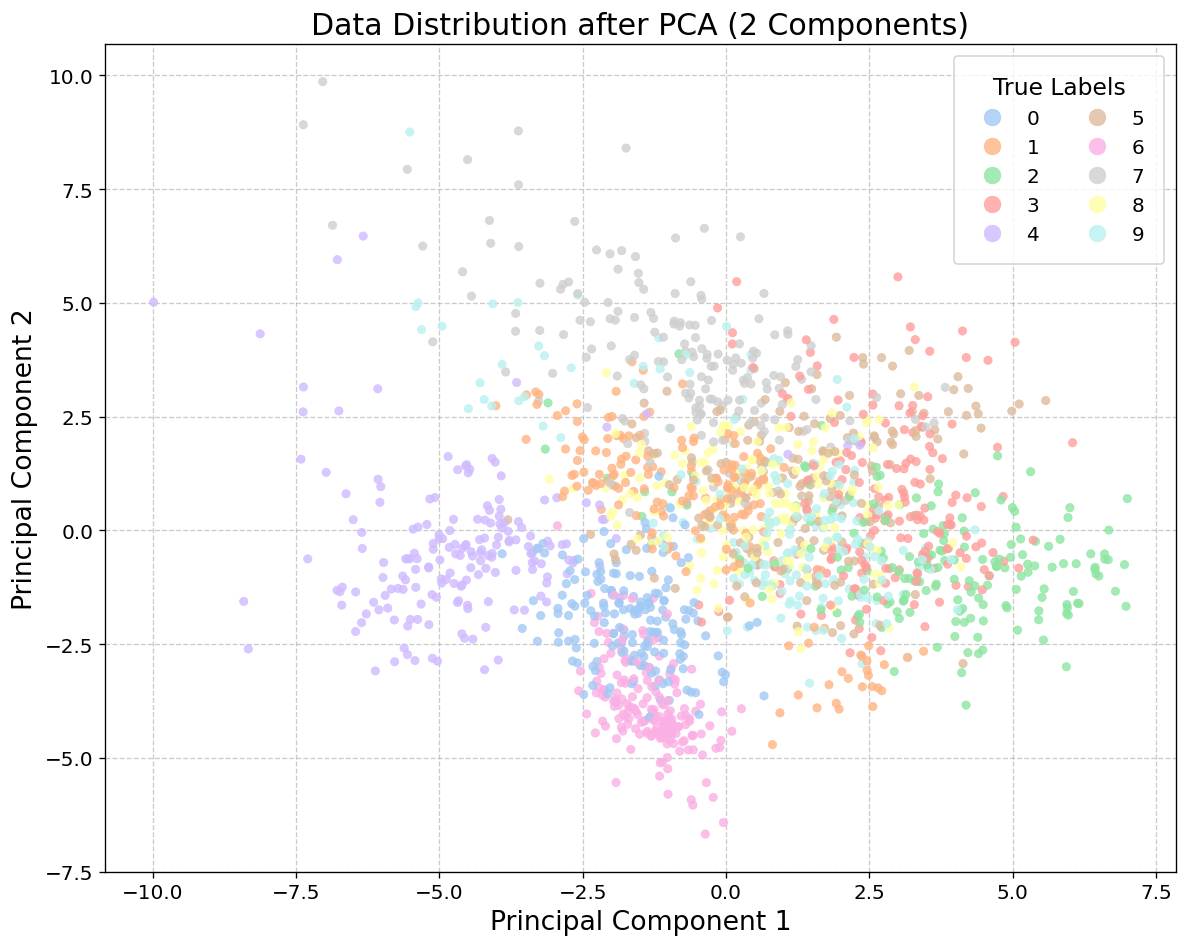

In [13]:
plot_pca_scatter(
    X_pca_2d,
    y,
    title='Data Distribution after PCA (2 Components)',
    palette='pastel',
)

## Kmeans


### Elbow Method


In [14]:
wcss = []
Ks = range(1, 16)
for k in Ks:
    kmeans = KMeans(
        n_init=10,
        n_clusters=k,
        init='k-means++',
        max_iter=500,
        random_state=RANDOM_STATE,
    )
    kmeans.fit(X_pca_2d)
    wcss.append(kmeans.inertia_)

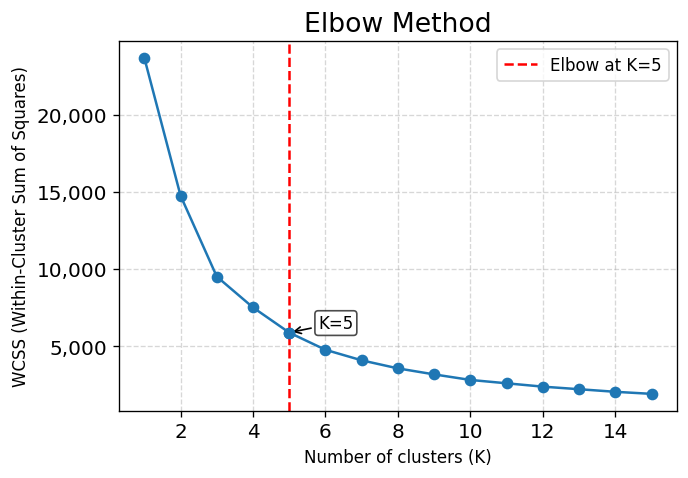

np.int64(5)

In [15]:
plot_elbow(Ks, wcss)

### KMeans (k=5)


In [16]:
kmeans_k5 = KMeans(
    n_clusters=5,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k5 = kmeans_k5.fit_predict(X_pca_2d)

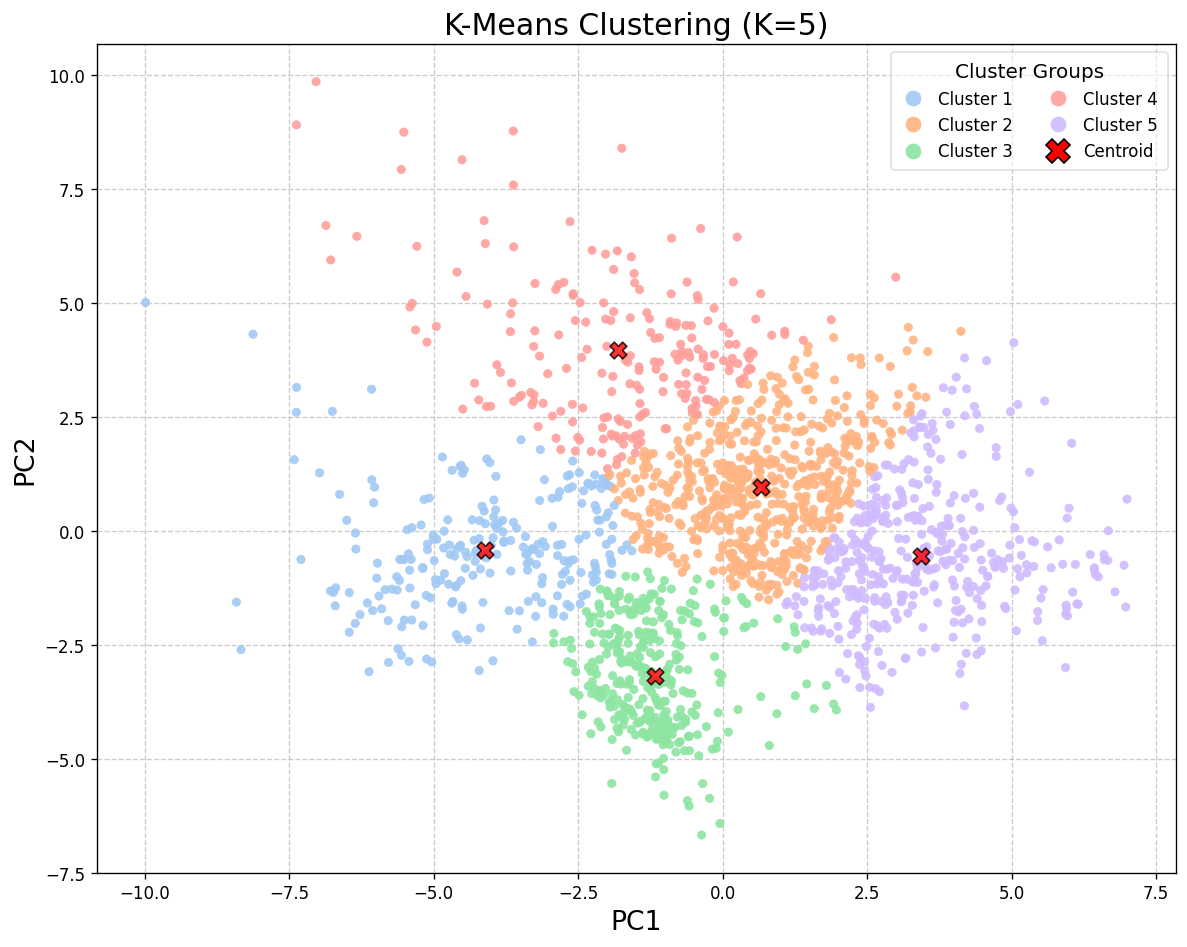

In [17]:
plot_clusters(
    km_labels_k5,
    X_pca_2d,
    title='K-Means Clustering (K=5)',
    palette='pastel',
)

### KMeans (k=10)


In [18]:
kmeans_k10 = KMeans(
    n_clusters=10,
    n_init=10,
    init='k-means++',
    max_iter=500,
    random_state=RANDOM_STATE,
)
km_labels_k10 = kmeans_k10.fit_predict(X_pca_2d)

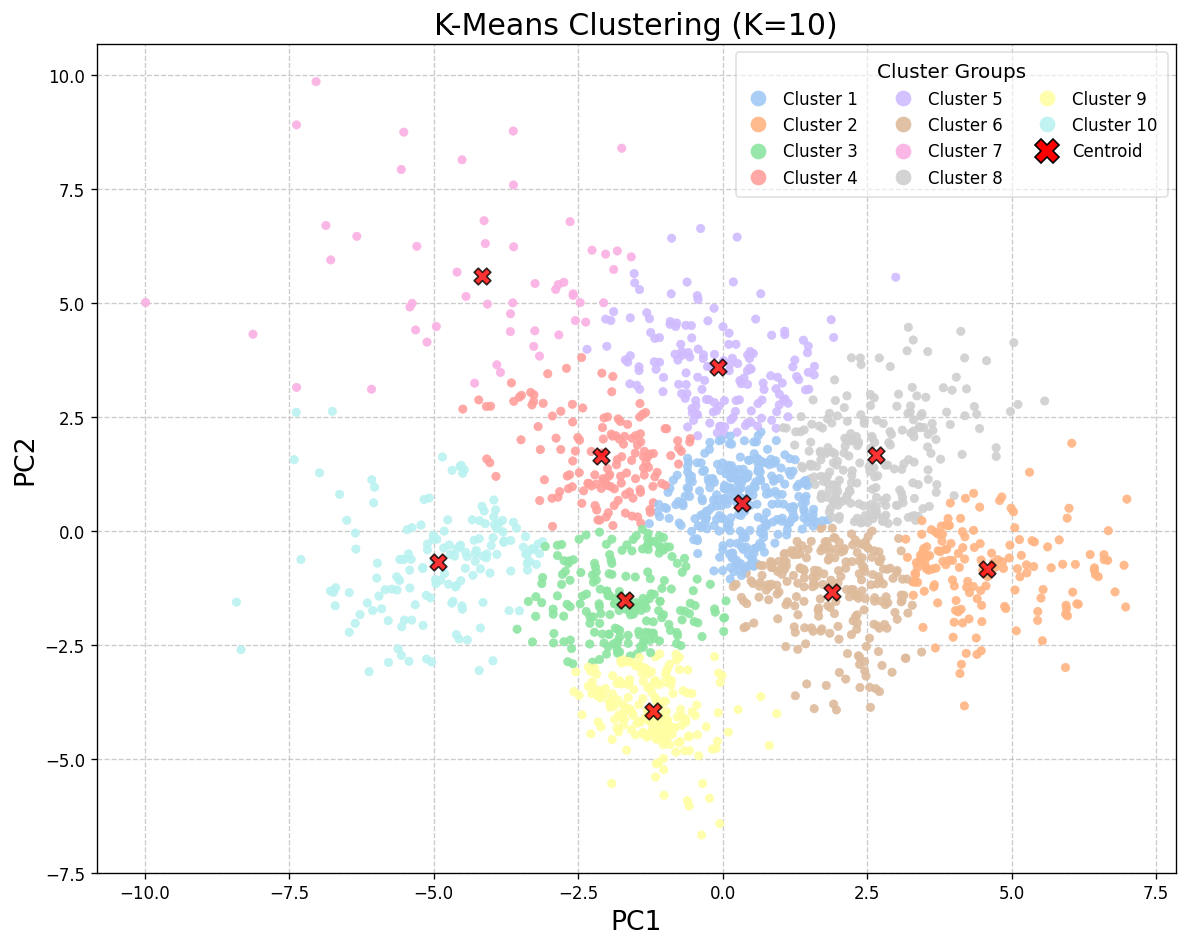

In [19]:
plot_clusters(
    km_labels_k10,
    X_pca_2d,
    title='K-Means Clustering (K=10)',
    palette='pastel',
)

### Evaluate KMeans Results


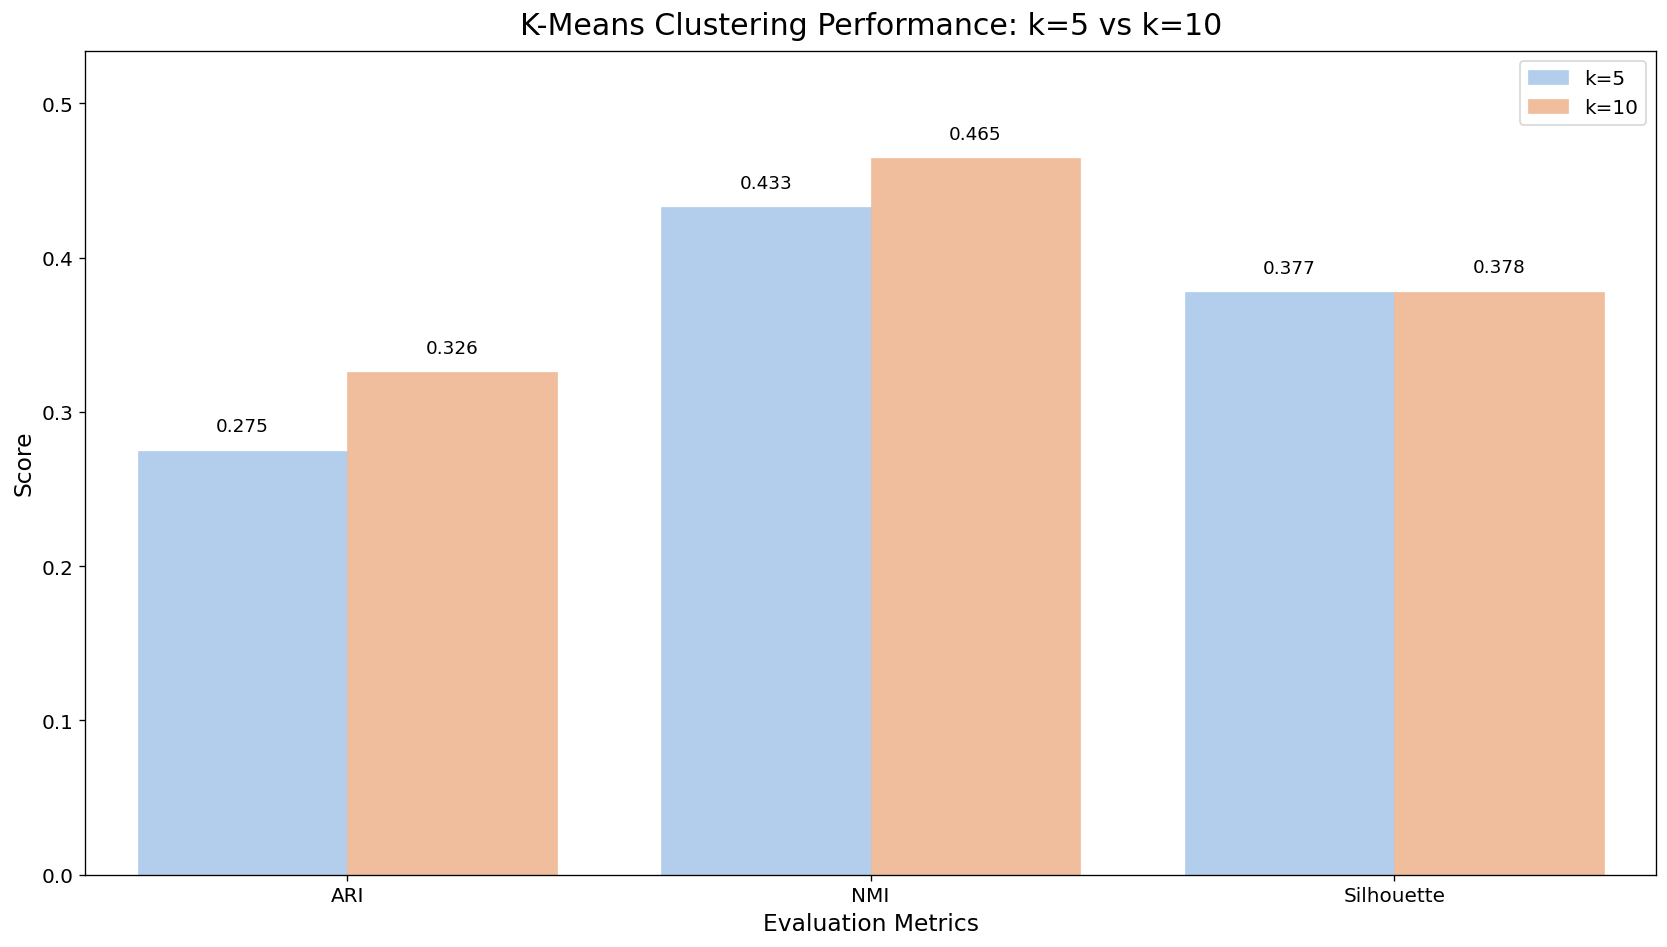

In [20]:
df_multi, fig_multi, ax_multi = kmeans_metrics_plot(
    runs=[
        {'label': 'k=5', 'true': y, 'labels': km_labels_k5, 'k': 5, 'inertia': kmeans_k5.inertia_},
        {'label': 'k=10', 'true': y, 'labels': km_labels_k10, 'k': 10, 'inertia': kmeans_k10.inertia_},
    ],
    X_data=X_pca_2d,
    metrics=[
        'adjusted_rand_score',
        'normalized_mutual_info',
        # "homogeneity_score",
        # "completeness_score",
        # "v_measure_score",
        'silhouette_score',
    ],
    palette='pastel',
)